# Peak SWE — which calibration subset handles the seasonal maximum best?

For every **station × season** the day with the **largest observed SWE** (Mag25 manual pits, ~bi-weekly)
is taken as the *peak SWE* and compared with the ΔSNOW output **of that same day**. The peaks are pooled
over all stations and seasons, giving one set of error metrics per validated run
(`dyn_rho_max_res/validation/nc/*.nc`), which are then summarised per calibration subset
(SP_all, SP_RG, Win21).

Two reference runs (nixmass defaults, no calibration) are shown alongside but not ranked. They are produced
by `run_dsnow_defaults.R` in this folder (`Rscript peak_SWE/run_dsnow_defaults.R`) from the Mag25 HS data:
- **ΔSNOW default** — original static-ρ_max model (`reference_runs/dsnow_default.nc`)
- **ΔSNOW2.0 default** — dynamic-ρ_max model (`reference_runs/dsnow2.0_default.nc`)

§ 5 asks **how much of the peak error is already made during accumulation**: per station-season the
accumulated HNW error (1 Nov → peak day) is set against the peak-SWE error.


In [1]:
from pathlib import Path

# Project root - located through the .projectroot marker file
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / ".projectroot").exists())

import sys, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display
warnings.filterwarnings("ignore")

sys.path.insert(0, str(ROOT))
from plot_style import apply_style, C, FIG, SUBSET_COLOR, SUBSET_LABEL, add_subplot_labels
apply_style()
plt.rcParams.update({"figure.dpi": 130})

# ── Paths ─────────────────────────────────────────────────────────────────────
NC_DIR        = ROOT / "calibration/calibration_rho_dyn/dyn_rho_max_res/validation/nc"
OUT_DIR       = ROOT / "peak_SWE"
MAG25_NC      = ROOT / "calibration/calibration_data/raw_data/mag25/slf_dataset/Mag25_all.nc"   # HS (m) that drives ΔSNOW
REF_RUNS      = {   # nixmass defaults, written by peak_SWE/run_dsnow_defaults.R
    "ΔSNOW default":    OUT_DIR / "reference_runs/dsnow_default.nc",      # static ρ_max
    "ΔSNOW2.0 default": OUT_DIR / "reference_runs/dsnow2.0_default.nc",   # dynamic ρ_max
}
PLOTS_DIR     = OUT_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================================== #
#  >>> SWITCHES <<<                                                           #
MIN_OBS       = 4                  # min. SWE observations a station-season needs to define a peak
DROP_STATIONS = {"Weisfluh_Joch"}  # no model output (same rule as the R validation)
MAX_ALT       =  None         # m a.s.l.: exclude stations above this altitude (None = keep all);
                                   # altitudes come from the `altitude` variable of MAG25_NC

# error decomposition (§ 5): HNW_obs exists Nov-Apr only, with isolated 1-day gaps (~23 % of days)
COV_MIN       = 0.6    # min. share of days with an HNW obs between 1 Nov and the peak day
SCALE_GAPS    = False  # False: gap days filled with the model's HNW (no model error assumed there)
                       # True:  observed-day error extrapolated to gap days (x 1/coverage)
# =========================================================================== #

SUBSET_DISPLAY = {"sp_all": SUBSET_LABEL.ALL, "sp_rg": SUBSET_LABEL.RAIN_GAUGE,
                  "sp_b2000": SUBSET_LABEL.BELOW_2000, "win21": "Win21"}
SUBSET_COL     = {"sp_all": SUBSET_COLOR.ALL, "sp_rg": SUBSET_COLOR.RAIN_GAUGE,
                  "sp_b2000": SUBSET_COLOR.BELOW_2000, "win21": C.WINKLER}
REF_STYLE      = {"ΔSNOW default": dict(color=C.DSNOW, ls=":"),
                  "ΔSNOW2.0 default": dict(color=C.DSNOW, ls="--")}
TOP_N          = 5                                                  # calibration favourites ringed + labelled in the rank plot (§ 7)

print("Setup complete.")

Setup complete.


---
## 1 — Extract the peak SWE per station and season

Season = hydrological year (1 Sep – 31 Aug), labelled by its start year, e.g. `2018/19`.
Only station-seasons with at least `MIN_OBS` observations are kept; stations in `DROP_STATIONS` and — if
`MAX_ALT` is set — above `MAX_ALT` m a.s.l. (Mag25 `altitude`) are excluded.
The bulk density on the peak day, ρ_bulk = SWE / HS (kg m⁻³), uses the Mag25 snow depth that also drives ΔSNOW,
so observed and modelled ρ_bulk share the same HS.


In [2]:
# ── Mag25 driving data: station altitude (exclusion switch) and the HS that drives the model ──
with xr.open_dataset(MAG25_NC) as ds:
    altitude = pd.Series(ds["altitude"].values, index=ds["station"].values.astype(str))   # m a.s.l.
    hs       = ds["HS"].to_pandas()                                                       # time x station, m
altitude.index, hs.index, hs.columns = altitude.index.str.strip(), hs.index.normalize(), hs.columns.str.strip()
too_high = set(altitude.index[altitude > MAX_ALT]) if MAX_ALT is not None else set()
EXCLUDE  = set(DROP_STATIONS) | too_high
print(f"excluded stations: {sorted(EXCLUDE)}"
      + (f"  ({len(too_high)} above MAX_ALT = {MAX_ALT} m)" if MAX_ALT is not None else "  (MAX_ALT off)"))


def load_long(nc_path):
    '''NetCDF -> long DataFrame of the days with a SWE observation.'''
    with xr.open_dataset(nc_path) as ds:
        names = [v.decode().strip() if isinstance(v, bytes) else str(v).strip()
                 for v in ds["station_name"].values]
        long = (ds[["SWE_obs", "SWE_mod"]].assign_coords(station=names)
                  .to_dataframe().reset_index())
        attrs = dict(ds.attrs)
    long = long[long["SWE_obs"].notna() & (long["SWE_obs"] >= 0)
                & ~long["station"].isin(EXCLUDE)]
    long["time"] = pd.to_datetime(long["time"])
    yr = np.where(long["time"].dt.month >= 9, long["time"].dt.year, long["time"].dt.year - 1)
    long["season"] = [f"{y}/{str(y + 1)[-2:]}" for y in yr]
    return long, attrs


def peak_swe(nc_path, run):
    '''One row per station-season: date and value of the max. observed SWE and the
    model SWE on that same day.'''
    long, _ = load_long(nc_path)
    g = long.groupby(["station", "season"])
    peak = long.loc[g["SWE_obs"].idxmax()].copy()
    peak["n_obs"] = g.size().values
    peak = peak[(peak["n_obs"] >= MIN_OBS) & peak["SWE_mod"].notna()]
    peak = peak.rename(columns={"time": "peak_date", "SWE_obs": "peak_obs", "SWE_mod": "peak_mod"})
    peak["run"] = run
    return peak[["run", "station", "season", "peak_date", "n_obs", "peak_obs", "peak_mod"]]


# ── all calibrated runs in NC_DIR + the two default reference runs ────────────
runs = {}   # run label -> dict(path, subset, phase, ref)
for p in sorted(NC_DIR.glob("*.nc")):
    with xr.open_dataset(p) as ds:
        a = dict(ds.attrs)
    subset, phase = a.get("subset", "?"), str(a.get("phase", "?"))
    if phase == "default":      # control run of the R validation -> replaced by REF_RUNS
        continue
    runs[f"{SUBSET_DISPLAY.get(subset, subset)} {phase}"] = dict(path=p, subset=subset, phase=phase,
                                                                  algorithm=a.get("algorithm", "?"), ref=False)
for name, p in REF_RUNS.items():
    assert p.exists(), f"{p.relative_to(ROOT)} missing - run:  Rscript peak_SWE/run_dsnow_defaults.R"
    runs[name] = dict(path=p, subset="reference", phase="default", algorithm="none", ref=True)

peaks = pd.concat([peak_swe(r["path"], name) for name, r in runs.items()], ignore_index=True)
peaks["subset"] = peaks["run"].map({k: v["subset"] for k, v in runs.items()})
peaks["ref"]    = peaks["run"].map({k: v["ref"]    for k, v in runs.items()})
peaks["err"]    = peaks["peak_mod"] - peaks["peak_obs"]

# ── bulk density on the peak day: ρ = SWE / HS with the Mag25 HS that also drives the model ──
peaks["hs"]      = [hs.at[t, s] for t, s in zip(peaks["peak_date"].dt.normalize(), peaks["station"])]
hs_snow          = peaks["hs"].where(peaks["hs"] > 0)   # no density without snow (never the case at a peak)
peaks["rho_obs"] = peaks["peak_obs"] / hs_snow           # kg m⁻³ (SWE in mm ≙ kg m⁻², HS in m)
peaks["rho_mod"] = peaks["peak_mod"] / hs_snow
peaks["rho_err"] = peaks["rho_mod"] - peaks["rho_obs"]

n_ss = peaks.groupby("run").size()
print(f"{len(runs)} runs ({sum(not r['ref'] for r in runs.values())} calibrated + {sum(r['ref'] for r in runs.values())} reference)")
print(f"{n_ss.min()}–{n_ss.max()} station-seasons per run "
      f"({peaks['station'].nunique()} stations, seasons {', '.join(sorted(peaks['season'].unique()))})")
alt_used = altitude.reindex(sorted(peaks["station"].unique())).sort_values()
items    = [f"{s} {int(a)}" for s, a in alt_used.items()]
print("station altitudes (m a.s.l.):\n  " + "\n  ".join(", ".join(items[i:i + 6]) for i in range(0, len(items), 6)))
peaks.to_csv(OUT_DIR / "peak_swe_per_station_season.csv", index=False)
display(peaks[peaks["run"] == "ΔSNOW2.0 default"].head(8))

excluded stations: ['Weisfluh_Joch']  (MAX_ALT off)


82 runs (80 calibrated + 2 reference)
123–123 station-seasons per run (22 stations, seasons 2016/17, 2017/18, 2018/19, 2019/20, 2020/21, 2021/22)
station altitudes (m a.s.l.):
  Gsteig 1195, Stoos 1280, Braunwald 1310, Adelboden 1350, Ulrichen 1350, Wiler 1405
  Muenster 1410, Sedrun 1420, Spluegen 1457, Fionnay 1500, Gantrisch 1510, Davos_Flueelastr 1560
  Malbun 1610, San_Bernadino 1640, Muerren 1650, Bourg_St_Pierre 1670, Zuoz 1710, Samnaun 1750
  Bivio 1770, Saas_Fee 1790, Maloja 1800, Juf 2117


,run,station,season,peak_date,n_obs,peak_obs,peak_mod,subset,ref,err,hs,rho_obs,rho_mod,rho_err
9963,ΔSNOW2.0 default,Adelboden,2016/17,2017-02-15 06:00:00,4,85.0,86.351497,reference,True,1.351497,0.32,265.625000,269.848429,4.223429
9964,ΔSNOW2.0 default,Adelboden,2017/18,2017-12-31 06:00:00,4,78.0,116.103105,reference,True,38.103105,0.30,260.000000,387.010350,127.010350
9965,ΔSNOW2.0 default,Adelboden,2018/19,2019-02-15 06:00:00,7,165.0,165.074216,reference,True,0.074216,0.61,270.491803,270.613469,0.121665
9966,ΔSNOW2.0 default,Adelboden,2020/21,2021-02-01 06:00:00,7,109.0,113.969972,reference,True,4.969972,0.38,286.842105,299.920980,13.078875
9967,ΔSNOW2.0 default,Adelboden,2021/22,2022-02-14 06:00:00,8,104.0,76.597572,reference,True,-27.402428,0.42,247.619048,182.375172,-65.243876
9968,ΔSNOW2.0 default,Bivio,2016/17,2017-03-14 06:00:00,5,162.0,147.540572,reference,True,-14.459428,0.59,274.576271,250.068766,-24.507505
9969,ΔSNOW2.0 default,Bivio,2017/18,2018-03-30 06:00:00,9,379.0,377.863081,reference,True,-1.136919,1.11,341.441441,340.417190,-1.024251
9970,ΔSNOW2.0 default,Bivio,2018/19,2019-04-15 06:00:00,10,440.0,434.609306,reference,True,-5.390694,1.10,400.000000,395.099369,-4.900631


---
## 2 — Pooled metrics per run

All station-season peaks of a run pooled into one sample: Bias, relative bias, RMSE, R² (model vs. observed peak SWE).


In [3]:
def metrics(obs, mod):
    res = mod - obs
    ss_tot = np.sum((obs - obs.mean()) ** 2)
    return pd.Series({
        "N":        len(obs),
        "Bias":     res.mean(),
        "Rel_BIAS": res.sum() / obs.sum(),
        "RMSE":     np.sqrt(np.mean(res ** 2)),
        "R2":       1 - np.sum(res ** 2) / ss_tot if ss_tot > 0 else np.nan,
    })

per_run = (peaks.groupby("run").apply(lambda d: metrics(d["peak_obs"].values, d["peak_mod"].values))
                .reset_index())
per_run["subset"] = per_run["run"].map({k: v["subset"] for k, v in runs.items()})
per_run["ref"]    = per_run["run"].map({k: v["ref"]    for k, v in runs.items()})
per_run["N"]      = per_run["N"].astype(int)
per_run = per_run.sort_values("RMSE").reset_index(drop=True)
per_run.to_csv(OUT_DIR / "peak_swe_metrics_per_run.csv", index=False)

refs = per_run[per_run["ref"]].set_index("run")
cal  = per_run[~per_run["ref"]].reset_index(drop=True)
cal.index += 1   # rank by RMSE

print("Reference runs:")
display(refs[["N", "Bias", "Rel_BIAS", "RMSE", "R2"]].round(3))
print(f"\nCalibrated runs ranked by peak-SWE RMSE (top 10 of {len(cal)}):")
display(cal[["run", "subset", "N", "Bias", "Rel_BIAS", "RMSE", "R2"]].head(10).round(3))

Reference runs:


,N,Bias,Rel_BIAS,RMSE,R2
run,,,,,
ΔSNOW2.0 default,123,-0.014,-0.000,39.703,0.898
ΔSNOW default,123,-13.742,-0.047,40.369,0.894



Calibrated runs ranked by peak-SWE RMSE (top 10 of 80):


,run,subset,N,Bias,Rel_BIAS,RMSE,R2
1,Win21 3A,win21,123,-12.123,-0.041,39.160,0.900
2,SP_RG 6C,sp_rg,123,2.667,0.009,39.239,0.900
3,Win21 6C,win21,123,-9.711,-0.033,39.451,0.899
4,Win21 4C,win21,123,-7.194,-0.025,39.511,0.899
5,Win21 6A,win21,123,-11.196,-0.038,39.635,0.898
6,SP_RG 4B,sp_rg,123,-3.904,-0.013,40.048,0.896
7,Win21 4B,win21,123,-10.682,-0.037,40.055,0.896
8,Win21 3C,win21,123,-9.706,-0.033,40.259,0.895
9,Win21 4A,win21,123,-11.106,-0.038,40.286,0.895
10,Win21 5B,win21,123,-15.375,-0.053,40.491,0.894


---
## 3 — Which subset handles the peak best?

Summary over the calibrated runs of each subset (one value per run) plus its best single run.


In [4]:
per_subset = (cal.groupby("subset")
                 .agg(n_runs=("run", "size"),
                      RMSE_median=("RMSE", "median"), RMSE_min=("RMSE", "min"), RMSE_max=("RMSE", "max"),
                      Bias_median=("Bias", "median"), RelBias_median=("Rel_BIAS", "median"),
                      R2_median=("R2", "median"),
                      best_run=("RMSE", lambda s: cal.loc[s.idxmin(), "run"]))
                 .sort_values("RMSE_median"))
per_subset.index = per_subset.index.map(SUBSET_DISPLAY)
display(per_subset.round(3))

best_median = per_subset.index[0]
best_single = cal.iloc[0]
print(f"→ Lowest median peak-SWE RMSE over its runs: {best_median} "
      f"({per_subset.iloc[0]['RMSE_median']:.1f} kg m⁻², median bias {per_subset.iloc[0]['Bias_median']:+.1f})")
print(f"→ Best single run: {best_single['run']} "
      f"(RMSE {best_single['RMSE']:.1f}, bias {best_single['Bias']:+.1f}, R² {best_single['R2']:.3f})")
for name, r in refs.iterrows():
    print(f"   reference {name:18s} RMSE {r['RMSE']:.1f}, bias {r['Bias']:+.1f}, R² {r['R2']:.3f}")

,n_runs,RMSE_median,RMSE_min,RMSE_max,Bias_median,RelBias_median,R2_median,best_run
subset,,,,,,,,
Win21,20,41.059,39.160,46.355,-13.175,-0.045,0.891,Win21 3A
SP_all,20,43.209,42.464,63.861,11.108,0.038,0.879,SP_all 4A
SP_b2000,20,46.578,44.316,73.704,16.781,0.057,0.859,SP_b2000 5C
SP_RG,20,49.423,39.239,53.086,-19.468,-0.067,0.841,SP_RG 6C


→ Lowest median peak-SWE RMSE over its runs: Win21 (41.1 kg m⁻², median bias -13.2)
→ Best single run: Win21 3A (RMSE 39.2, bias -12.1, R² 0.900)
   reference ΔSNOW2.0 default   RMSE 39.7, bias -0.0, R² 0.898
   reference ΔSNOW default      RMSE 40.4, bias -13.7, R² 0.894


---
## 4 — Plots

**a/b)** one point per calibrated run: peak-SWE RMSE and bias, grouped by subset; dashed/dotted lines = the two
default reference runs.
**c–e)** observed vs. modelled peak SWE (every station-season) for the best run of each subset.


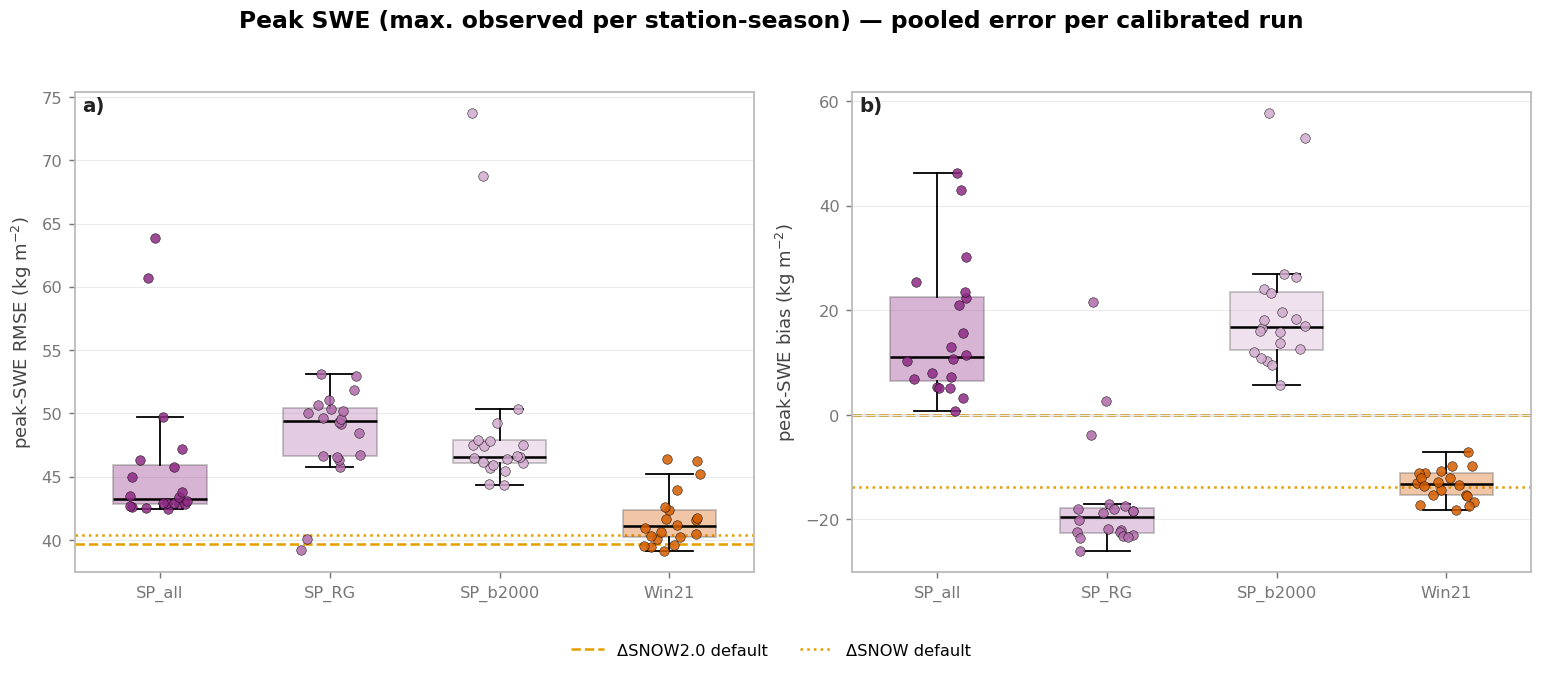

In [5]:
subsets = [s for s in SUBSET_DISPLAY if s in cal["subset"].values]
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 2, figsize=FIG.BOX4)
for ax, col, ylabel in zip(axes, ["RMSE", "Bias"], ["peak-SWE RMSE (kg m$^{-2}$)", "peak-SWE bias (kg m$^{-2}$)"]):
    data = [cal.loc[cal["subset"] == s, col].values for s in subsets]
    bp = ax.boxplot(data, positions=range(len(subsets)), widths=0.55, patch_artist=True, showfliers=False, zorder=2)
    for patch, s in zip(bp["boxes"], subsets):
        patch.set_facecolor(SUBSET_COL[s]); patch.set_alpha(0.35); patch.set_edgecolor("#555555")
    for i, s in enumerate(subsets):
        v = cal.loc[cal["subset"] == s, col].values
        ax.scatter(i + rng.uniform(-0.18, 0.18, len(v)), v, s=28, c=SUBSET_COL[s],
                   edgecolor="k", linewidth=0.3, alpha=0.85, zorder=3)
    for name, r in refs.iterrows():
        ax.axhline(r[col], lw=1.4, zorder=1, **REF_STYLE[name])
    if col == "Bias":
        ax.axhline(0, color="grey", lw=0.8, zorder=1)
    ax.set_xticks(range(len(subsets))); ax.set_xticklabels([SUBSET_DISPLAY[s] for s in subsets])
    ax.set_ylabel(ylabel)
add_subplot_labels(axes)
handles = [Line2D([0], [0], lw=1.4, label=n, **REF_STYLE[n]) for n in refs.index]
fig.legend(handles=handles, loc="lower center", ncol=len(handles), frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Peak SWE (max. observed per station-season) — pooled error per calibrated run", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0.04, 1, 0.95))
fig.savefig(PLOTS_DIR / "01_peak_swe_metrics_by_subset.png", **FIG.SAVE)
plt.show()

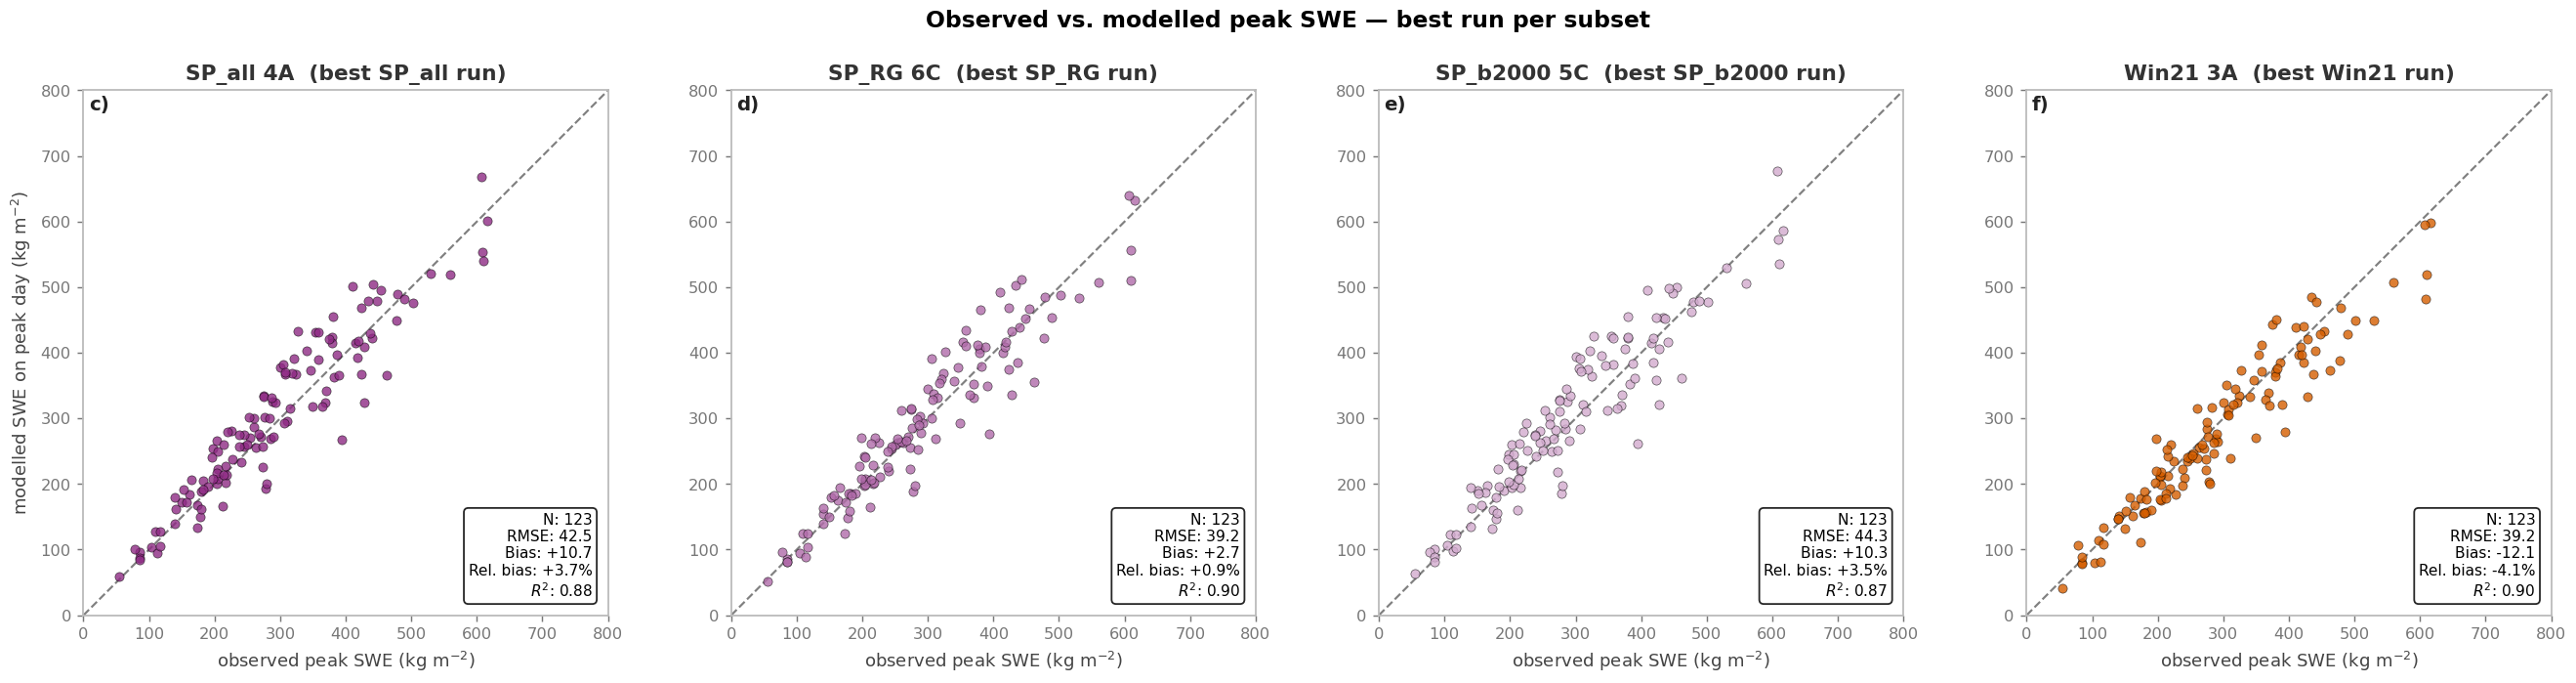

In [6]:
best_runs = [per_subset.loc[SUBSET_DISPLAY[s], "best_run"] for s in subsets]
lim = (0, np.ceil(peaks[["peak_obs", "peak_mod"]].max().max() / 100) * 100)

fig, axes = plt.subplots(1, len(best_runs), figsize=(5.2 * len(best_runs), 5.2))
for ax, s, run in zip(np.atleast_1d(axes), subsets, best_runs):
    d = peaks[peaks["run"] == run]
    m = per_run.set_index("run").loc[run]
    ax.plot(lim, lim, "--", color="gray", lw=1.2, zorder=1)
    ax.scatter(d["peak_obs"], d["peak_mod"], s=26, c=SUBSET_COL[s], edgecolor="k", linewidth=0.3, alpha=0.8, zorder=3)
    ax.text(0.97, 0.03, f"N: {int(m['N'])}\nRMSE: {m['RMSE']:.1f}\nBias: {m['Bias']:+.1f}\nRel. bias: {m['Rel_BIAS']:+.1%}\n$R^2$: {m['R2']:.2f}",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))
    ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
    ax.set_xlabel("observed peak SWE (kg m$^{-2}$)")
    ax.set_title(f"{run}  (best {SUBSET_DISPLAY[s]} run)", fontweight="semibold")
    ax.grid(False)
np.atleast_1d(axes)[0].set_ylabel("modelled SWE on peak day (kg m$^{-2}$)")
add_subplot_labels(axes, start="c")
fig.suptitle("Observed vs. modelled peak SWE — best run per subset", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(PLOTS_DIR / "02_peak_swe_scatter_best_runs.png", **FIG.SAVE)
plt.show()

---
## 5 — Where does the peak error come from? The accumulation error

Per station-season the model's **accumulation error** up to the peak day is set against the peak error:

- `acc_obs`, `acc_mod` = Σ HNW_obs, Σ HNW_mod from 1 Nov to the peak day
- `d_hnw` = `acc_mod` − `acc_obs` — **accumulation error**
- `d_peak` = SWE_mod − SWE_obs on the peak day



In [7]:
def decompose(nc_path, pk):
    '''Per station-season: accumulation (1 Nov -> peak day, obs and model), its error and the peak error.'''
    with xr.open_dataset(nc_path) as ds:
        names = [v.decode().strip() if isinstance(v, bytes) else str(v).strip() for v in ds["station_name"].values]
        t  = pd.DatetimeIndex(ds["time"].values)
        ho = pd.DataFrame(ds["HNW_obs"].transpose("time", "station").values, index=t, columns=names)
        hm = pd.DataFrame(ds["HNW_mod"].transpose("time", "station").values, index=t, columns=names)
    cov, acc_obs, acc_mod = [], [], []
    for r in pk.itertuples():
        start = pd.Timestamp(int(r.season[:4]), 11, 1)
        o, m = ho.loc[start:r.peak_date, r.station], hm.loc[start:r.peak_date, r.station]
        ok = o.notna() & m.notna()
        c = ok.mean() if len(ok) else 0.0
        cov.append(c)
        if c == 0:
            acc_obs.append(np.nan); acc_mod.append(np.nan)
        elif SCALE_GAPS:   # observed days only, scaled to full coverage
            acc_obs.append(o[ok].sum() / c); acc_mod.append(m[ok].sum() / c)
        else:              # gap days filled with the model -> d_hnw = error on observed days only
            acc_obs.append(o[ok].sum() + m[~ok].sum()); acc_mod.append(m.sum())
    out = pk.copy()
    out["cov"], out["acc_obs"], out["acc_mod"] = cov, acc_obs, acc_mod
    out["d_hnw"]  = out["acc_mod"] - out["acc_obs"]
    out["d_peak"] = out["peak_mod"] - out["peak_obs"]
    return out

decomp = pd.concat([decompose(r["path"], peaks[peaks["run"] == name]) for name, r in runs.items()],
                   ignore_index=True)
n_all = len(decomp)
decomp = decomp[decomp["cov"] >= COV_MIN].reset_index(drop=True)
print(f"coverage 1 Nov -> peak: median {decomp['cov'].median():.2f}; "
      f"{n_all - len(decomp)} of {n_all} station-season rows dropped (cov < {COV_MIN})")

# consistency of the two observation products (run-independent) vs. the model's own consistency
d0 = decomp[decomp["run"] == "ΔSNOW2.0 default"]
loss_obs, loss_mod = d0["acc_obs"] - d0["peak_obs"], d0["acc_mod"] - d0["peak_mod"]
print(f"\nimplied loss before the peak, obs (acc_obs - peak_obs):  median {loss_obs.median():6.1f}  sd {loss_obs.std():6.1f}  "
      f"< -20 kg/m2 in {(loss_obs < -20).sum():2d} of {len(d0)}   corr(acc_obs, peak_obs) = {d0['acc_obs'].corr(d0['peak_obs']):.2f}")
print(f"same for ΔSNOW2.0 default   (acc_mod - peak_mod):  median {loss_mod.median():6.1f}  sd {loss_mod.std():6.1f}  "
      f"< -20 kg/m2 in {(loss_mod < -20).sum():2d} of {len(d0)}   corr(acc_mod, peak_mod) = {d0['acc_mod'].corr(d0['peak_mod']):.2f}")

def dec_summary(d):
    return pd.Series({
        "N":         len(d),
        "bias_peak": d["d_peak"].mean(),
        "bias_hnw":  d["d_hnw"].mean(),
        "rms_peak":  np.sqrt((d["d_peak"] ** 2).mean()),
        "rms_hnw":   np.sqrt((d["d_hnw"] ** 2).mean()),
        "r_hnw":     d["d_peak"].corr(d["d_hnw"]),
    })

dec_run = decomp.groupby("run").apply(dec_summary)
dec_run["N"] = dec_run["N"].astype(int)
dec_run = dec_run.join(per_run.set_index("run")[["subset", "ref", "RMSE"]])

print("\nReference runs:")
display(dec_run[dec_run["ref"]].drop(columns=["subset", "ref", "RMSE"]).round(3))

dec_subset = (dec_run[~dec_run["ref"]].groupby("subset")
              [["bias_peak", "bias_hnw", "rms_peak", "rms_hnw", "r_hnw"]]
              .median().loc[subsets])
dec_subset.index = dec_subset.index.map(SUBSET_DISPLAY)
print("\nCalibrated runs — median per subset (kg m⁻² / correlation):")
display(dec_subset.round(3))

coverage 1 Nov -> peak: median 0.78; 164 of 10086 station-season rows dropped (cov < 0.6)

implied loss before the peak, obs (acc_obs - peak_obs):  median   66.2  sd   81.6  < -20 kg/m2 in 12 of 121   corr(acc_obs, peak_obs) = 0.82
same for ΔSNOW2.0 default   (acc_mod - peak_mod):  median   14.5  sd   38.3  < -20 kg/m2 in  0 of 121   corr(acc_mod, peak_mod) = 0.95

Reference runs:


,N,bias_peak,bias_hnw,rms_peak,rms_hnw,r_hnw
run,,,,,,
ΔSNOW default,121,-13.611,-47.774,40.605,78.576,0.303
ΔSNOW2.0 default,121,-0.108,-42.983,40.014,75.116,0.247



Calibrated runs — median per subset (kg m⁻² / correlation):


,bias_peak,bias_hnw,rms_peak,rms_hnw,r_hnw
subset,,,,,
SP_all,10.646,46.600,43.305,79.074,0.203
SP_RG,-20.097,25.194,49.753,68.718,0.230
SP_b2000,16.231,50.086,46.454,82.423,0.203
Win21,-13.140,-47.629,41.337,78.243,0.317


---
## 6 — Helper functions

- `plot_peak_scatter(subset, phase, algorithm="Nelder-Mead")` — 2 × 3 figure of observed vs. modelled values on
  the peak day (all station-seasons): columns ΔSNOW default, ΔSNOW2.0 default and the chosen calibrated run;
  top row peak SWE, bottom row bulk density ρ_bulk = SWE / HS (kg m⁻³). `subset` = `sp_all` / `sp_rg` / `win21`
  (or `SP_all` / `SP_RG` / `Win21`). `save=True` writes the figure to `plots/`. Returns the pooled metrics per panel.


In [8]:
PEAK_VAR = {   # var -> columns of `peaks`, axis labels, unit
    "SWE": dict(obs="peak_obs", mod="peak_mod", unit="kg m$^{-2}$",
                x="observed peak SWE", y="modelled SWE on peak day"),
    "rho": dict(obs="rho_obs", mod="rho_mod", unit="kg m$^{-3}$",
                x="observed $\\rho_\\mathrm{bulk}$ on peak day", y="modelled $\\rho_\\mathrm{bulk}$ on peak day"),
}

def peak_panel(ax, run, var, lim):
    """Observed vs. modelled `var` on the peak day, all station-seasons of `run`, with the pooled metrics box."""
    cfg = PEAK_VAR[var]
    d   = peaks[peaks["run"] == run].dropna(subset=[cfg["obs"], cfg["mod"]])
    m   = metrics(d[cfg["obs"]].values, d[cfg["mod"]].values)
    m["Med_Bias"] = (d[cfg["mod"]] - d[cfg["obs"]]).median()
    ax.plot(lim, lim, "--", color="gray", lw=1.2, zorder=1)
    ax.scatter(d[cfg["obs"]], d[cfg["mod"]], s=26, c=SUBSET_COL.get(runs[run]["subset"], C.DSNOW),
               edgecolor="k", linewidth=0.3, alpha=0.8, zorder=3)
    ax.text(0.97, 0.03, f"N: {int(m['N'])}\nRMSE: {m['RMSE']:.1f}\nBias: {m['Bias']:+.1f}\n"
                        f"Median bias: {m['Med_Bias']:+.1f}\nRel. bias: {m['Rel_BIAS']:+.1%}\n$R^2$: {m['R2']:.2f}",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))
    ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
    ax.set_xlabel(f"{cfg['x']} ({cfg['unit']})")
    ax.grid(False)
    return m


def plot_peak_scatter(subset, phase, algorithm="Nelder-Mead", save=False):
    """2 x 3 figure: observed vs. modelled peak SWE (top row) and bulk density SWE/HS on the peak day
    (bottom row) for ΔSNOW default, ΔSNOW2.0 default and the chosen calibrated run (columns)."""
    key  = {v: k for k, v in SUBSET_DISPLAY.items()}.get(subset, subset)
    hits = [n for n, r in runs.items()
            if r["subset"] == key and str(r["phase"]) == str(phase) and r["algorithm"] == algorithm]
    if not hits:
        avail = sorted({(r["subset"], r["phase"], r["algorithm"]) for r in runs.values()})
        raise ValueError(f"no run with subset={subset!r}, phase={phase!r}, algorithm={algorithm!r}. "
                         f"Available (subset, phase, algorithm): {avail}")
    chosen = hits[0]
    cols   = [*REF_RUNS, chosen]                       # ΔSNOW default | ΔSNOW2.0 default | chosen run

    fig, axes = plt.subplots(2, len(cols), figsize=(5.2 * len(cols), 5.2 * 2))
    out = {}
    for row, (var, cfg) in zip(axes, PEAK_VAR.items()):
        lim = (0, np.ceil(peaks[[cfg["obs"], cfg["mod"]]].max().max() / 100) * 100)   # same limits along a row
        for ax, run in zip(row, cols):
            out[(run, var)] = peak_panel(ax, run, var, lim)
        row[0].set_ylabel(f"{cfg['y']} ({cfg['unit']})")
    for ax, run in zip(axes[0], cols):
        ax.set_title(run + (f"  ({algorithm})" if run == chosen else ""), fontweight="semibold")
    add_subplot_labels(axes)
    fig.tight_layout()
    if save:
        fig.savefig(PLOTS_DIR / f"peak_scatter_{key}_{phase}_{algorithm}.png", **FIG.SAVE)
    plt.show()
    return pd.DataFrame(out).T.rename_axis(["run", "var"]).astype({"N": int})


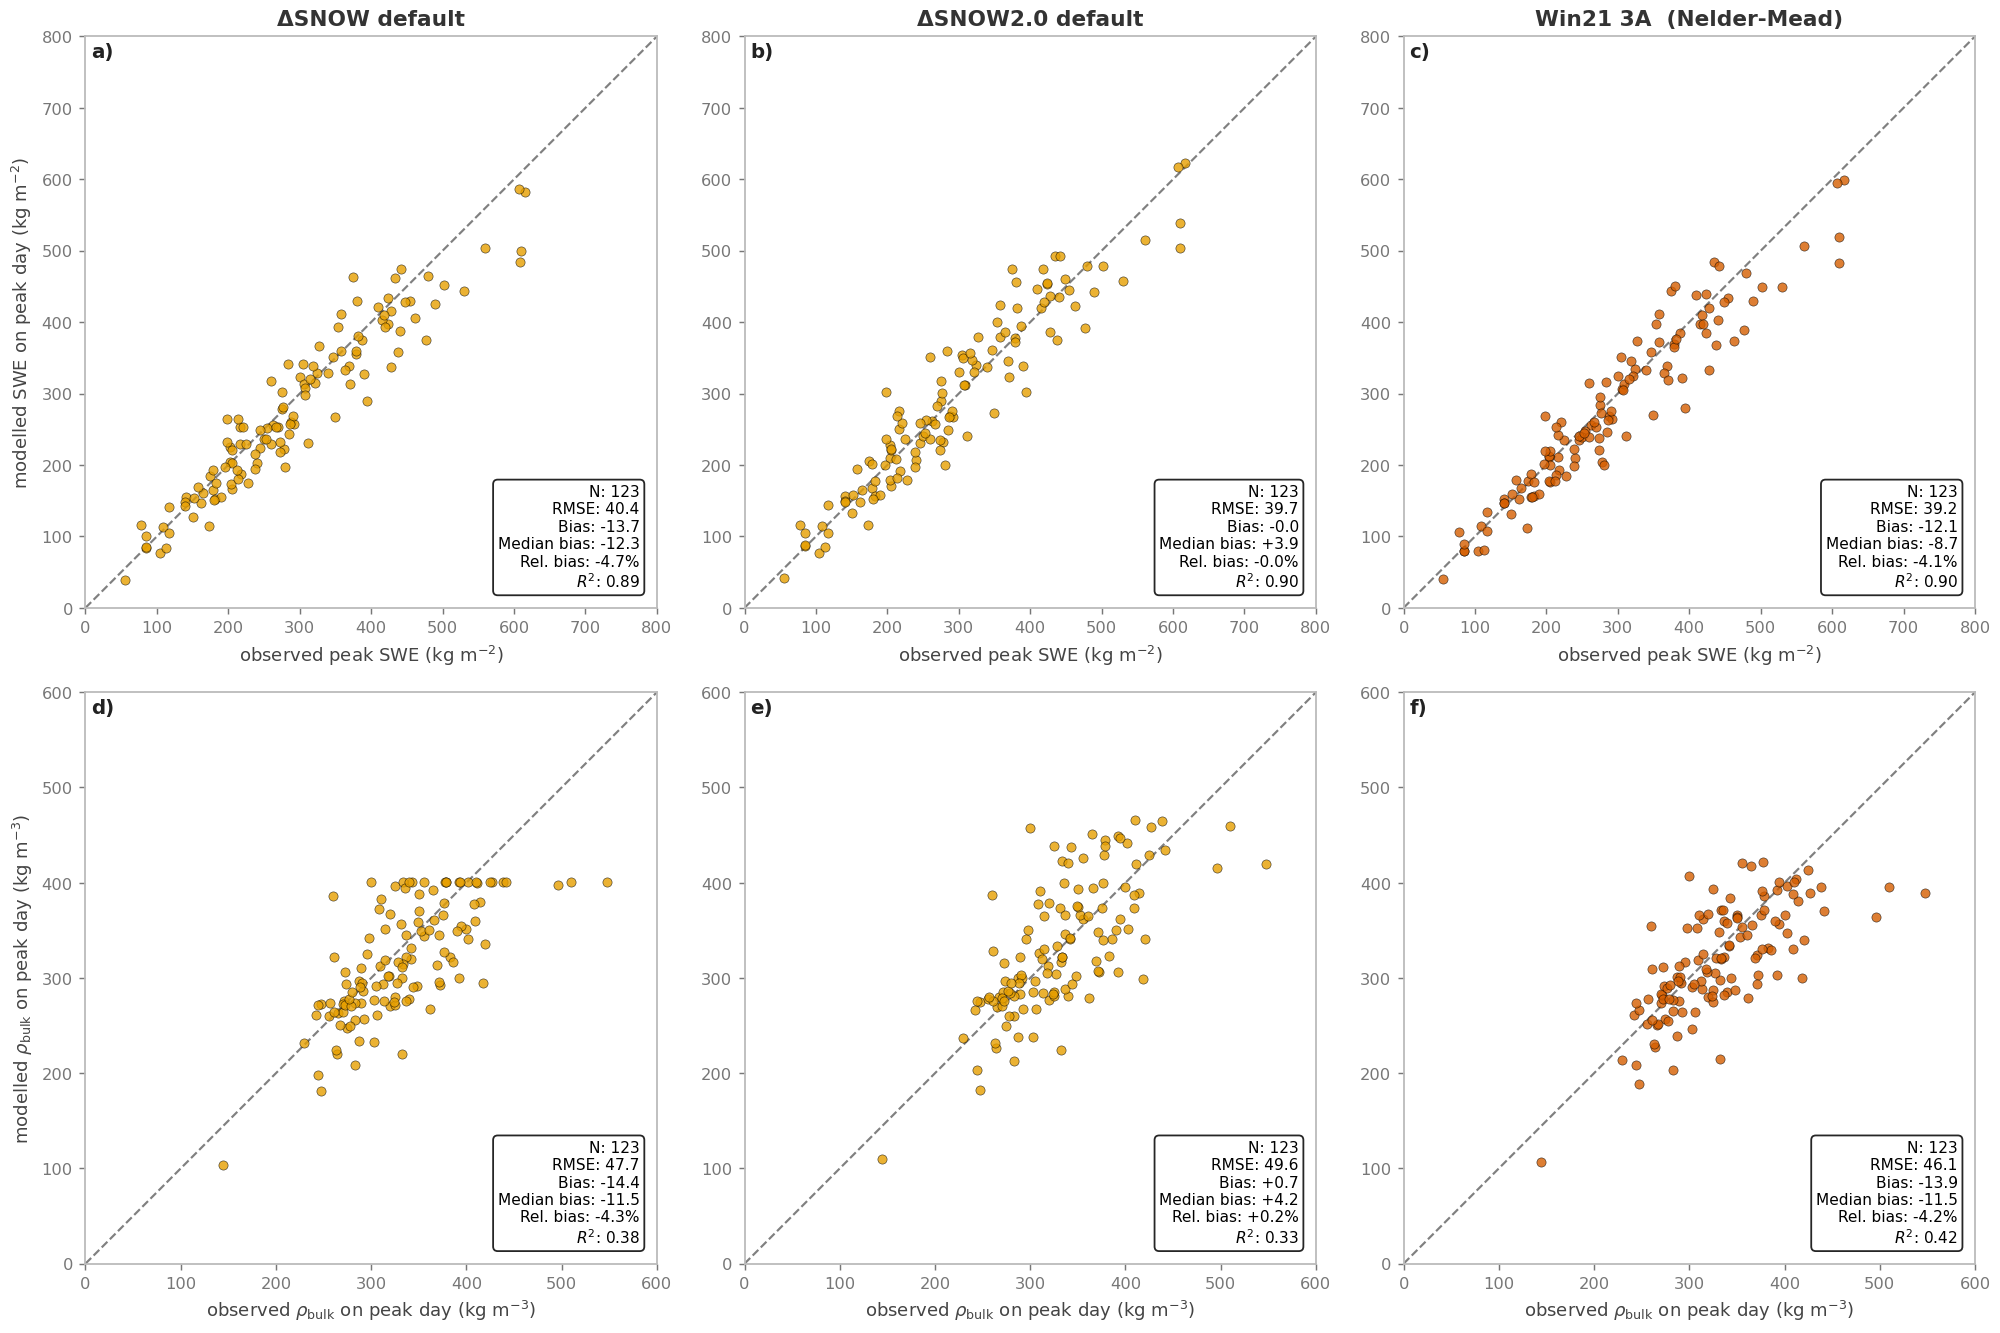

,,N,Bias,Rel_BIAS,RMSE,R2,Med_Bias
run,var,,,,,,
ΔSNOW default,SWE,123,-13.741518,-0.046970,40.369157,0.894195,-12.269608
ΔSNOW2.0 default,SWE,123,-0.014008,-0.000048,39.703367,0.897656,3.888055
Win21 3A,SWE,123,-12.122591,-0.041436,39.160290,0.900437,-8.739053
ΔSNOW default,rho,123,-14.382126,-0.043336,47.684104,0.382844,-11.507564
ΔSNOW2.0 default,rho,123,0.730881,0.002202,49.637454,0.331246,4.227493
Win21 3A,rho,123,-13.895924,-0.041871,46.056594,0.424254,-11.498754


In [9]:
plot_peak_scatter("win21", "3A")

---
## 7 — Calibration combined rank vs. peak-SWE rank

x: the **combined rank** of the dynamic-ρ_max calibration (`rho_dyn_results_combined_rank_phases.csv`, written by
`calibration/calibration_rho_dyn/rho_dyn_results_overview.ipynb`: mean of the
SWE-RMSE rank and the |HNW rel. bias| rank of the full validation, ordinal, 1 = best).
y: the same runs ranked by the **|rel. bias| of their peak-SWE estimate** (§ 2, 1 = closest to zero).
Runs on the 1:1 line are ranked alike by both; rings = the calibration's top `TOP_N`. ρ_S = Spearman rank correlation.

80 runs in both rankings


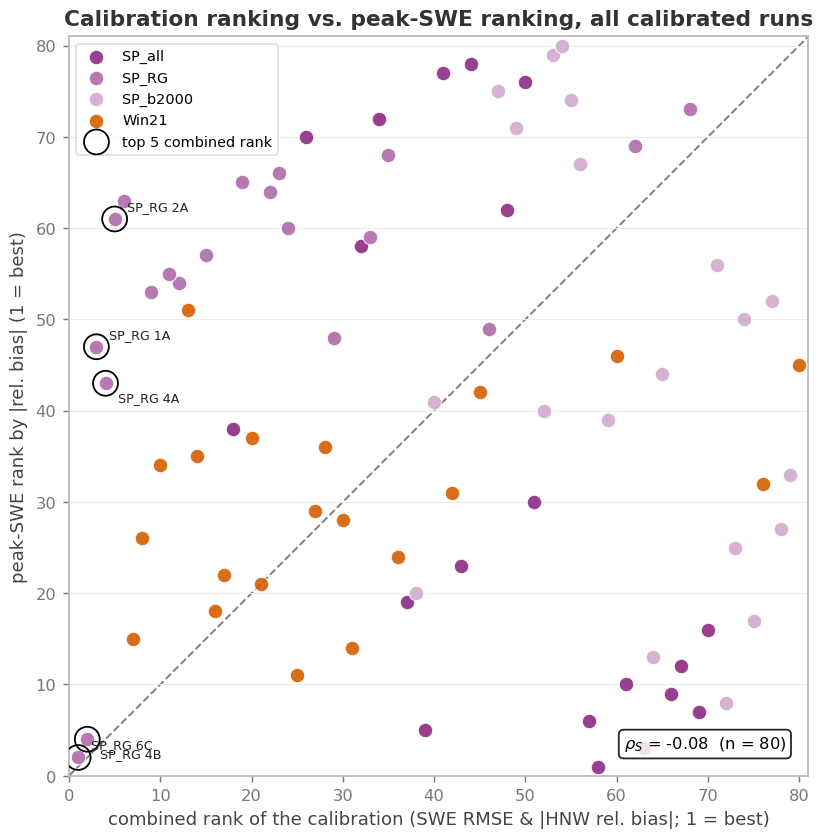

,subset,rank_peak,Rel_BIAS,rank_cal,rank_combined,rank_swe,rank_hnw
run,,,,,,,
SP_all 1B,sp_all,1,0.002,58,51.5,38.0,65.0
SP_RG 6C,sp_rg,2,0.009,1,8.5,15.0,2.0
SP_all 5C,sp_all,3,0.011,63,54.0,40.0,68.0
SP_RG 4B,sp_rg,4,-0.013,2,12.5,10.0,15.0
SP_all 6D,sp_all,5,0.017,39,40.5,39.0,42.0
SP_all 2C,sp_all,6,0.018,57,50.5,41.0,60.0
SP_all 4C,sp_all,7,0.018,69,57.5,45.0,70.0
SP_b2000 1B,sp_b2000,8,0.020,72,63.5,49.0,78.0
SP_all 5A,sp_all,9,0.023,66,54.5,43.0,66.0


In [10]:
# ── combined rank of the calibration vs. rank of the peak-SWE estimate ────────
RANK_CSV = ROOT / "calibration/calibration_rho_dyn/dyn_rho_max_res/rho_dyn_results_combined_rank_phases.csv"

# calibration side: ordinal combined rank (mean of the SWE-RMSE and |HNW rel. bias| ranks) per run
cr = pd.read_csv(RANK_CSV)
cr["run"] = cr["subset"].map(SUBSET_DISPLAY).fillna(cr["subset"]) + " " + cr["phase"].astype(str)
cr = (cr.set_index("run")[["rank", "rank_combined", "rank_swe", "rank_hnw"]]
        .rename(columns={"rank": "rank_cal"}))

# peak side: calibrated runs ordered by |rel. bias| of the peak-SWE estimate (1 = closest to zero)
rk = cal.set_index("run")[["subset", "Rel_BIAS", "RMSE"]].copy()
rk["rank_peak"] = rk["Rel_BIAS"].abs().rank(method="min").astype(int)
rk = rk.join(cr, how="inner")
n  = len(rk)
unmatched = sorted(set(cal["run"]).symmetric_difference(cr.index))
print(f"{n} runs in both rankings" + (f"; not in both: {unmatched}" if unmatched else ""))

rho_s = rk["rank_cal"].corr(rk["rank_peak"], method="spearman")
top   = rk.nsmallest(TOP_N, "rank_cal")          # the calibration's favourites

fig, ax = plt.subplots(figsize=(6.6, 6.6))
ax.plot([0, n + 1], [0, n + 1], "--", color="gray", lw=1.1, zorder=1)
for s in [s for s in SUBSET_DISPLAY if s in rk["subset"].values]:
    d = rk[rk["subset"] == s]
    ax.scatter(d["rank_cal"], d["rank_peak"], s=65, c=SUBSET_COL[s], edgecolor="white",
               linewidth=0.6, alpha=0.9, zorder=3, label=SUBSET_DISPLAY[s])
ax.scatter(top["rank_cal"], top["rank_peak"], s=190, facecolor="none", edgecolor="k",
           linewidth=1.0, zorder=4, label=f"top {TOP_N} combined rank")
for i, (run, r) in enumerate(top.iterrows()):          # alternate above/below: neighbours don't overlap
    ax.annotate(run, (r["rank_cal"], r["rank_peak"]), xytext=(7, 5 if i % 2 == 0 else -10),
                textcoords="offset points", fontsize=7, color="#222222", zorder=5)
ax.text(0.97, 0.03, f"$\\rho_S$ = {rho_s:+.2f}  (n = {n})", transform=ax.transAxes, ha="right",
        va="bottom", fontsize=9, bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))
ax.set_xlim(0, n + 1); ax.set_ylim(0, n + 1); ax.set_aspect("equal")
ax.set_xlabel("combined rank of the calibration (SWE RMSE & |HNW rel. bias|; 1 = best)")
ax.set_ylabel("peak-SWE rank by |rel. bias| (1 = best)")
ax.set_title("Calibration ranking vs. peak-SWE ranking, all calibrated runs", fontweight="semibold")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "06_rank_combined_vs_rank_peak_relbias.png", **FIG.SAVE)
plt.show()

display(rk.sort_values("rank_peak")[["subset", "rank_peak", "Rel_BIAS", "rank_cal", "rank_combined",
                                     "rank_swe", "rank_hnw"]].head(10).round(3))